In [1]:
# Here we are importing all the libraries required for the model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

Here after importing the libraries we will be loading the dataset onto the code

In [2]:
accident = pd.read_csv("Accident.csv", low_memory=False)
vehicle = pd.read_csv("Vehicle.csv", low_memory=False)

print("Accident dataset shape:", accident.shape)
print("Vehicle dataset shape:", vehicle.shape)
# The shape of the datasets is displayed

Accident dataset shape: (200352, 23)
Vehicle dataset shape: (365470, 37)


In [3]:
accident.columns = (
    accident.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

vehicle.columns = (
    vehicle.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

print(accident.columns.tolist())
print(vehicle.columns.tolist())

['ACCIDENT_NO', 'ACCIDENT_DATE', 'ACCIDENT_TIME', 'ACCIDENT_TYPE', 'ACCIDENT_TYPE_DESC', 'DAY_OF_WEEK', 'DAY_WEEK_DESC', 'DCA_CODE', 'DCA_DESC', 'LIGHT_CONDITION', 'NODE_ID', 'NO_OF_VEHICLES', 'NO_PERSONS_KILLED', 'NO_PERSONS_INJ_2', 'NO_PERSONS_INJ_3', 'NO_PERSONS_NOT_INJ', 'NO_PERSONS', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'ROAD_GEOMETRY_DESC', 'SEVERITY', 'SPEED_ZONE', 'RMA']
['ACCIDENT_NO', 'VEHICLE_ID', 'VEHICLE_YEAR_MANUF', 'VEHICLE_DCA_CODE', 'INITIAL_DIRECTION', 'ROAD_SURFACE_TYPE', 'ROAD_SURFACE_TYPE_DESC', 'REG_STATE', 'VEHICLE_BODY_STYLE', 'VEHICLE_MAKE', 'VEHICLE_MODEL', 'VEHICLE_POWER', 'VEHICLE_TYPE', 'VEHICLE_TYPE_DESC', 'VEHICLE_WEIGHT', 'CONSTRUCTION_TYPE', 'FUEL_TYPE', 'NO_OF_WHEELS', 'NO_OF_CYLINDERS', 'SEATING_CAPACITY', 'TARE_WEIGHT', 'TOTAL_NO_OCCUPANTS', 'CARRY_CAPACITY', 'CUBIC_CAPACITY', 'FINAL_DIRECTION', 'DRIVER_INTENT', 'VEHICLE_MOVEMENT', 'TRAILER_TYPE', 'VEHICLE_COLOUR_1', 'VEHICLE_COLOUR_2', 'CAUGHT_FIRE', 'INITIAL_IMPACT', 'LAMPS', 'LEVEL_OF_DAMAGE', 'TOWED

In [4]:
print("ACCIDENT_NO" in accident.columns)
print("ACCIDENT_NO" in vehicle.columns)

print("Missing accident numbers:")
print(accident["ACCIDENT_NO"].isna().sum())
print(vehicle["ACCIDENT_NO"].isna().sum())

True
True
Missing accident numbers:
0
0


In [5]:
accident["ACCIDENT_DATE"] = pd.to_datetime(
    accident["ACCIDENT_DATE"],
    dayfirst=True,
    errors="coerce"
)

accident["ACCIDENT_HOUR"] = pd.to_datetime(
    accident["ACCIDENT_TIME"],
    errors="coerce"
).dt.hour

accident["ACCIDENT_YEAR"] = accident["ACCIDENT_DATE"].dt.year
accident["ACCIDENT_MONTH"] = accident["ACCIDENT_DATE"].dt.month

/var/folders/jh/zmx439_564qd141wrywkgyj00000gn/T/ipykernel_33825/3516006948.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  accident["ACCIDENT_DATE"] = pd.to_datetime(
/var/folders/jh/zmx439_564qd141wrywkgyj00000gn/T/ipykernel_33825/3516006948.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  accident["ACCIDENT_HOUR"] = pd.to_datetime(


In [6]:
severity_code = (
    accident["SEVERITY"]
    .astype(str)
    .str.strip()
    .str.extract(r"^([1-4])")[0]
)

accident["SERIOUS_CRASH"] = severity_code.isin(["1", "2"]).astype(int)

print(accident["SERIOUS_CRASH"].value_counts())
print(accident["SERIOUS_CRASH"].value_counts(normalize=True))

SERIOUS_CRASH
0    124946
1     75406
Name: count, dtype: int64
SERIOUS_CRASH
0    0.623632
1    0.376368
Name: proportion, dtype: float64


Here we are classifying the accidents based on their severities as in fatal or non fatal

In [7]:
vehicle["VEHICLE_YEAR_MANUF"] = pd.to_numeric(
    vehicle["VEHICLE_YEAR_MANUF"],
    errors="coerce"
)

vehicle["TOTAL_NO_OCCUPANTS"] = pd.to_numeric(
    vehicle["TOTAL_NO_OCCUPANTS"],
    errors="coerce"
)

vehicle["VEHICLE_WEIGHT"] = pd.to_numeric(
    vehicle["VEHICLE_WEIGHT"],
    errors="coerce"
)

In [8]:
vehicle.loc[
    (vehicle["VEHICLE_YEAR_MANUF"] < 1900) |
    (vehicle["VEHICLE_YEAR_MANUF"] > 2026),
    "VEHICLE_YEAR_MANUF"
] = np.nan

Here we have removed all the irrealistic manufacture dates of the vehicles 

In [9]:
vehicle["VEHICLE_TYPE"] = (
    vehicle["VEHICLE_TYPE"]
    .astype(str)
    .str.strip()
    .str.zfill(2)
)

vehicle["MOTORCYCLE"] = vehicle["VEHICLE_TYPE"].isin(
    ["10", "11", "12"]
).astype(int)

vehicle["BICYCLE"] = (
    vehicle["VEHICLE_TYPE"] == "13"
).astype(int)

vehicle["HEAVY_VEHICLE"] = vehicle["VEHICLE_TYPE"].isin(
    ["06", "07", "08", "60", "61", "62", "63", "72"]
).astype(int)

In [10]:
vehicle_summary = vehicle.groupby("ACCIDENT_NO").agg(
    VEHICLE_RECORDS=("VEHICLE_ID", "count"),
    DIFFERENT_VEHICLE_TYPES=("VEHICLE_TYPE", "nunique"),
    AVERAGE_VEHICLE_YEAR=("VEHICLE_YEAR_MANUF", "mean"),
    AVERAGE_OCCUPANTS=("TOTAL_NO_OCCUPANTS", "mean"),
    TOTAL_OCCUPANTS=("TOTAL_NO_OCCUPANTS", "sum"),
    AVERAGE_VEHICLE_WEIGHT=("VEHICLE_WEIGHT", "mean"),
    MOTORCYCLE_INVOLVED=("MOTORCYCLE", "max"),
    BICYCLE_INVOLVED=("BICYCLE", "max"),
    HEAVY_VEHICLE_INVOLVED=("HEAVY_VEHICLE", "max")
).reset_index()

print(vehicle_summary.head())
print(vehicle_summary.shape)

    ACCIDENT_NO  VEHICLE_RECORDS  DIFFERENT_VEHICLE_TYPES  \
0  T20120000009                1                        1   
1  T20120000012                2                        1   
2  T20120000013                2                        2   
3  T20120000018                1                        1   
4  T20120000021                1                        1   

   AVERAGE_VEHICLE_YEAR  AVERAGE_OCCUPANTS  TOTAL_OCCUPANTS  \
0                1996.0                2.0              2.0   
1                1995.0                1.5              3.0   
2                2003.5                0.5              1.0   
3                1983.0                1.0              1.0   
4                1998.0                3.0              3.0   

   AVERAGE_VEHICLE_WEIGHT  MOTORCYCLE_INVOLVED  BICYCLE_INVOLVED  \
0                     NaN                    0                 0   
1                  1450.0                    0                 0   
2                     NaN                    0    

In [11]:
data = accident.merge(
    vehicle_summary,
    on="ACCIDENT_NO",
    how="inner"
)

data["AVERAGE_VEHICLE_AGE"] = (
    data["ACCIDENT_YEAR"] - data["AVERAGE_VEHICLE_YEAR"]
)

data.loc[
    (data["AVERAGE_VEHICLE_AGE"] < 0) |
    (data["AVERAGE_VEHICLE_AGE"] > 100),
    "AVERAGE_VEHICLE_AGE"
] = np.nan

print("Integrated dataset shape:", data.shape)
print(data.head())

Integrated dataset shape: (200343, 37)
    ACCIDENT_NO ACCIDENT_DATE ACCIDENT_TIME  ACCIDENT_TYPE  \
0  T20120002354    2012-01-31      10:35:00              1   
1  T20120002508    2012-02-02      07:55:00              1   
2  T20120003232    2012-02-10      14:20:00              1   
3  T20120004288    2012-02-17      08:40:00              1   
4  T20120004516    2012-02-24      15:30:00              2   

       ACCIDENT_TYPE_DESC  DAY_OF_WEEK DAY_WEEK_DESC  DCA_CODE  \
0  Collision with vehicle            3       Tuesday       121   
1  Collision with vehicle            5      Thursday       121   
2  Collision with vehicle            6        Friday       121   
3  Collision with vehicle            6        Friday       143   
4       Struck Pedestrian            6        Friday       101   

                                            DCA_DESC  LIGHT_CONDITION  ...  \
0                                      RIGHT THROUGH                1  ...   
1                                  

In [12]:
print("Duplicate accident numbers:")
print(data["ACCIDENT_NO"].duplicated().sum())

Duplicate accident numbers:
0


In [13]:
numeric_features = [
    "ACCIDENT_HOUR",
    "ACCIDENT_MONTH",
    "NO_OF_VEHICLES",
    "NO_PERSONS",
    "VEHICLE_RECORDS",
    "DIFFERENT_VEHICLE_TYPES",
    "AVERAGE_VEHICLE_AGE",
    "AVERAGE_OCCUPANTS",
    "TOTAL_OCCUPANTS",
    "AVERAGE_VEHICLE_WEIGHT",
    "MOTORCYCLE_INVOLVED",
    "BICYCLE_INVOLVED",
    "HEAVY_VEHICLE_INVOLVED"
]

categorical_features = [
    "ACCIDENT_TYPE_DESC",
    "DAY_WEEK_DESC",
    "LIGHT_CONDITION",
    "ROAD_GEOMETRY_DESC",
    "SPEED_ZONE"
]

In [14]:
numeric_features = [
    column for column in numeric_features
    if column in data.columns
]

categorical_features = [
    column for column in categorical_features
    if column in data.columns
]

features = numeric_features + categorical_features

X = data[features]
y = data["SERIOUS_CRASH"]

print("Features used:")
print(features)

print("\nTarget distribution:")
print(y.value_counts())

Features used:
['ACCIDENT_HOUR', 'ACCIDENT_MONTH', 'NO_OF_VEHICLES', 'NO_PERSONS', 'VEHICLE_RECORDS', 'DIFFERENT_VEHICLE_TYPES', 'AVERAGE_VEHICLE_AGE', 'AVERAGE_OCCUPANTS', 'TOTAL_OCCUPANTS', 'AVERAGE_VEHICLE_WEIGHT', 'MOTORCYCLE_INVOLVED', 'BICYCLE_INVOLVED', 'HEAVY_VEHICLE_INVOLVED', 'ACCIDENT_TYPE_DESC', 'DAY_WEEK_DESC', 'LIGHT_CONDITION', 'ROAD_GEOMETRY_DESC', 'SPEED_ZONE']

Target distribution:
SERIOUS_CRASH
0    124940
1     75403
Name: count, dtype: int64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 160274
Testing observations: 40069


#### Here we have divided training and testing data like 80 percent training data and 20 percent testing data

In [16]:
numeric_process = Pipeline(steps=[
    ("missing", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_process = Pipeline(steps=[
    ("missing", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=10
    ))
])

preprocess = ColumnTransformer(transformers=[
    ("numeric", numeric_process, numeric_features),
    ("categorical", categorical_process, categorical_features)
])

In [17]:
random_forest = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('missing',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ACCIDENT_HOUR',
                                                   'ACCIDENT_MONTH',
                                                   'NO_OF_VEHICLES',
                                                   'NO_PERSONS',
                                                   'VEHICLE_RECORDS',
                                                   'DIFFERENT_VEHICLE_TYPES',
                                                   'AVERAGE_VEHICLE_AGE',
                                                   'AVERAGE_OCCUPANTS',
                                                   'TOTAL_OCCUPANTS',
                                                   'AVERAGE_VEHICLE_W...
                                                  Pipeline(steps=[('missing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=10))]),
                                                  ['ACCIDENT_TYPE_DESC',
                                                   'DAY_WEEK_DESC',
                                                   'LIGHT_CONDITION',
                                                   'ROAD_GEOMETRY_DESC',
                                                   'SPEED_ZONE'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [18]:
rf_prediction = random_forest.predict(X_test)
rf_score = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(classification_report(y_test, rf_prediction))

print(
    "Balanced accuracy:",
    round(balanced_accuracy_score(y_test, rf_prediction), 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, rf_score), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test, rf_score), 4)
)

Random Forest Results
              precision    recall  f1-score   support

           0       0.73      0.64      0.68     24988
           1       0.50      0.60      0.55     15081

    accuracy                           0.63     40069
   macro avg       0.61      0.62      0.61     40069
weighted avg       0.64      0.63      0.63     40069

Balanced accuracy: 0.6208
ROC-AUC: 0.6633
PR-AUC: 0.5264


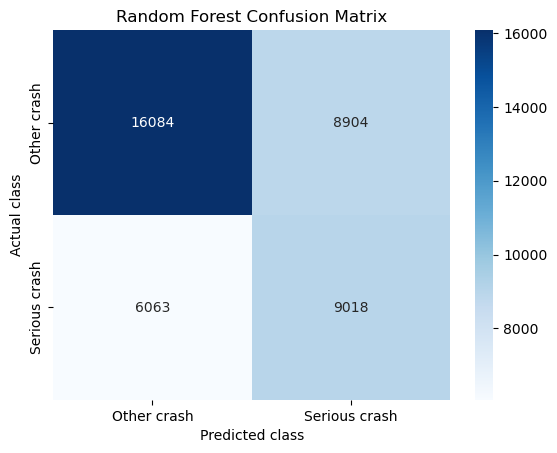

In [19]:
rf_matrix = confusion_matrix(y_test, rf_prediction)

sns.heatmap(
    rf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Other crash", "Serious crash"],
    yticklabels=["Other crash", "Serious crash"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()

In [20]:
svm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42,
        dual="auto",
        max_iter=5000
    ))
])

svm.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('missing',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ACCIDENT_HOUR',
                                                   'ACCIDENT_MONTH',
                                                   'NO_OF_VEHICLES',
                                                   'NO_PERSONS',
                                                   'VEHICLE_RECORDS',
                                                   'DIFFERENT_VEHICLE_TYPES',
                                                   'AVERAGE_VEHICLE_AGE',
                                                   'AVERAGE_OCCUPANTS',
                                                   'TOTAL_OCCUPANTS',
                                                   'AVERAGE_VEHICLE_W...
                                                   'HEAVY_VEHICLE_INVOLVED']),
                                                 ('categorical',
                                                  Pipeline(steps=[('missing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=10))]),
                                                  ['ACCIDENT_TYPE_DESC',
                                                   'DAY_WEEK_DESC',
                                                   'LIGHT_CONDITION',
                                                   'ROAD_GEOMETRY_DESC',
                                                   'SPEED_ZONE'])])),
                ('model',
                 LinearSVC(class_weight='balanced', max_iter=5000,
                           random_state=42))])

In [21]:
svm_prediction = svm.predict(X_test)
svm_score = svm.decision_function(X_test)

print("Support Vector Machine Results")
print(classification_report(y_test, svm_prediction))

print(
    "Balanced accuracy:",
    round(balanced_accuracy_score(y_test, svm_prediction), 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, svm_score), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test, svm_score), 4)
)

Support Vector Machine Results
              precision    recall  f1-score   support

           0       0.72      0.65      0.68     24988
           1       0.50      0.58      0.54     15081

    accuracy                           0.62     40069
   macro avg       0.61      0.61      0.61     40069
weighted avg       0.64      0.62      0.63     40069

Balanced accuracy: 0.6141
ROC-AUC: 0.6538
PR-AUC: 0.5162


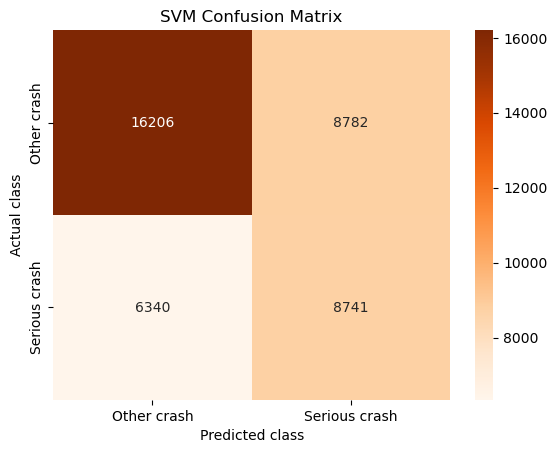

In [22]:
svm_matrix = confusion_matrix(y_test, svm_prediction)

sns.heatmap(
    svm_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Other crash", "Serious crash"],
    yticklabels=["Other crash", "Serious crash"]
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()

In [23]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Support Vector Machine"
    ],
    "Precision": [
        precision_score(y_test, rf_prediction),
        precision_score(y_test, svm_prediction)
    ],
    "Serious Crash Recall": [
        recall_score(y_test, rf_prediction),
        recall_score(y_test, svm_prediction)
    ],
    "F1-Score": [
        f1_score(y_test, rf_prediction),
        f1_score(y_test, svm_prediction)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, rf_prediction),
        balanced_accuracy_score(y_test, svm_prediction)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_score),
        roc_auc_score(y_test, svm_score)
    ],
    "PR-AUC": [
        average_precision_score(y_test, rf_score),
        average_precision_score(y_test, svm_score)
    ]
})

results.iloc[:, 1:] = results.iloc[:, 1:].round(4)

results

,Model,Precision,Serious Crash Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC
0,Random Forest,0.5032,0.5980,0.5465,0.6208,0.6633,0.5264
1,Support Vector Machine,0.4988,0.5796,0.5362,0.6141,0.6538,0.5162


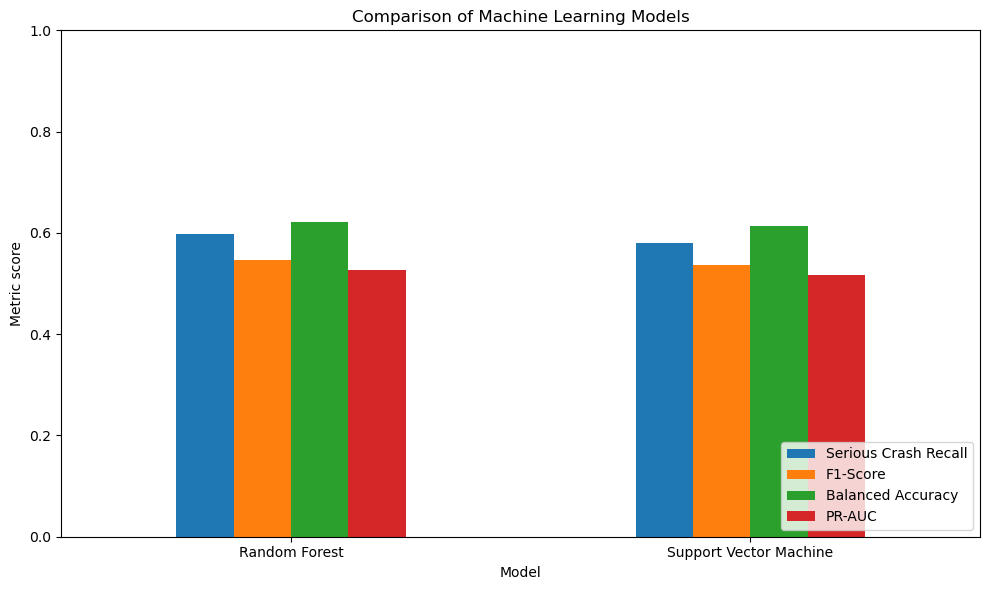

In [24]:
results.set_index("Model")[
    ["Serious Crash Recall", "F1-Score", "Balanced Accuracy", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Metric score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()